<a href="https://colab.research.google.com/github/emiliomercuri/FundEngAmb2026/blob/main/Codes/Exemplo__Velocidade_Terminal_de_sedimentac%CC%A7a%CC%83o_(regime_intermedia%CC%81rio_de_arrasto).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exemplo: Velocidade Terminal de sedimentação (regime intermediário de arrasto)

Calcule a velocidade terminal de sedimentação $v_t$ para uma partícula com diâmetro de 1 mm e densidade de 2 g cm$^{-3}$ suspensa em água a uma temperatura de 10°C.

## Solução

vamos baixar a tabela do livro estudada em sala:

In [1]:
!gdown 1ETYR1QviBMhJehbvw9AzYKPWgSUvTo6p

Downloading...
From: https://drive.google.com/uc?id=1ETYR1QviBMhJehbvw9AzYKPWgSUvTo6p
To: /content/tabela_stokes_newton.png
100% 203k/203k [00:00<00:00, 22.0MB/s]


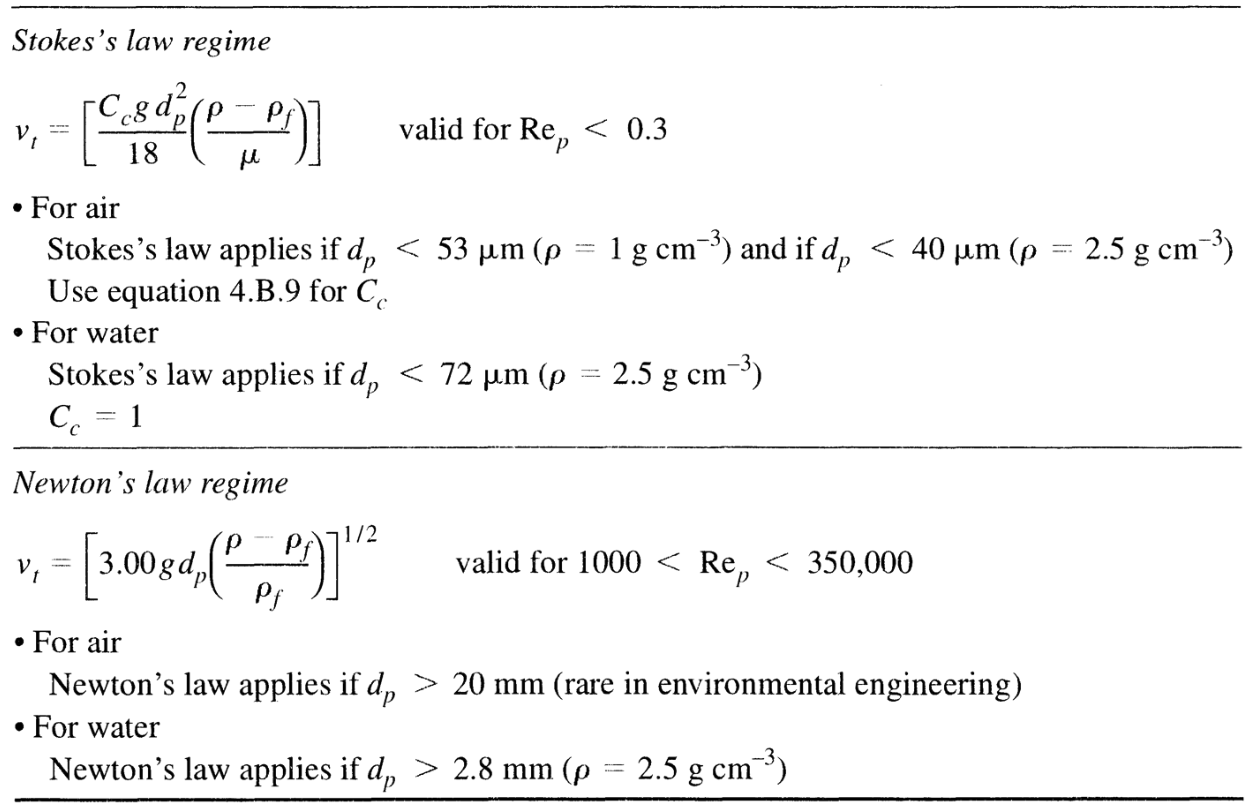

In [2]:
x, y = 1254, 808
from IPython.display import Image
Image("tabela_stokes_newton.png", width = x/2, height = y/2)

partícula com diâmetro de 1 mm e densidade de 2 g cm$^{-3}$ suspensa em água

De acordo com a tabela para a água, veja que o diâmetro da partícula vai cair no regime intermediário.

$d_p = 1$ mm não cai nem na lei de Newton nem Stokes

# Regime intermediário

Para encontrar a velocidade vamos usar as 3 equações:

$$
\operatorname{Re}_p=\frac{d_p V_{\infty} \rho_f}{\mu}
$$

$$
C_d =\frac{24}{\operatorname{Re}_p}\left(1+0.14 \operatorname{Re}_p^{0.7}\right) \quad \quad  0.3<\operatorname{Re}_p<1000 \quad \quad  \text { Regime Intermediário}
$$

$$
v_t=\left[\frac{4 g d_p}{3 C_d}\left(\frac{\rho-\rho_f}{\rho_f}\right)\right]^{1 / 2} \quad \rho>\rho_f
$$

**Podemos resolver para a velocidade com uma solução iterativa**

### Viscosidade

A viscosidade da água (g/cm/s) varia com a temperatura (em Kelvin) de acordo com:

$$\mu=1.856 \times 10^{-13} \exp \left(\frac{4209}{T}+0.04527 T - 3.376 \times 10^{-5} \, T^2\right)$$

Conversão de Kelvin para Celsius

$T_C = T_K - 273.15$

In [3]:
import numpy

In [4]:
T_C = 10 # oC
T   = T_C + 273.15

# função para viscosidade (g/cm/s)
def visc(T):
  return 1.856*10**(-13)*numpy.exp(4209/T+ 0.04527*T -(3.376*10**(-5))*T**2)

viscosidade = visc(T)
print("A viscosidade é ",viscosidade, "g cm-1 s-1")

A viscosidade é  0.013052950123494134 g cm-1 s-1


## Solução iterativa

Substituindo as propriedades físicas ($\mu$, $d_p$, $\rho$, $g = 980$ cm s$^{-2}$ e $\rho_f = 1$ g cm$^{-3}$) nas 3 equações temos:

$$
\begin{aligned}
\operatorname{Re}_p & =7.69 v_t \\
C_d & =\frac{24}{\operatorname{Re}_p}\left(1+0.14 \operatorname{Re}_p^{0.7}\right) \\
v_t & =11.4 C_d^{-1 / 2}
\end{aligned}
$$

In [5]:
## chute inicial para v
v = 15 # cm/s

for i in range(10):
  Re = 7.69 * v
  Cd = (24/Re)*(1+0.14*Re**0.7)
  v = 11.4*Cd**(-0.5)
  print(v)

11.306192164945557
10.601979064461347
10.442955625514545
10.405649103586839
10.39681844765744
10.394723753780893
10.394226628047706
10.394108633026653
10.394080625587298
10.394073977663354


Para 3 casas decimais chegamos a $v_t = 10.394$ m/s